<a href="https://colab.research.google.com/github/Fares-pr0g/ML-journey-ep-2-Experimenting-with-NN-s-in-PyTorch/blob/main/LearningPyTorch03%3A%20Computer%20Vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Let's work on some computer vision problems and learn its basics

In [1]:
# importing relevant dependencies
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

In [2]:
# We'll pick the FashionMnist dataset

#training data
train_data= datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform= ToTensor(),
)

#testing data
test_data= datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform= ToTensor(),
)

In [3]:
image, label= train_data[0]
print(image.shape)
print(f"Possible classes:\n{train_data.classes}")

torch.Size([1, 28, 28])
Possible classes:
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [4]:
#Let's see how many samples we have

len(train_data.data),len(test_data.data)

(60000, 10000)

## Visualizing the data

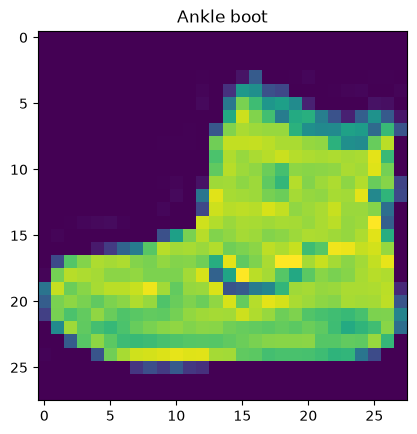

In [5]:
image,label= train_data[0]
plt.imshow(image.squeeze())
plt.title(train_data.classes[label])
plt.show()

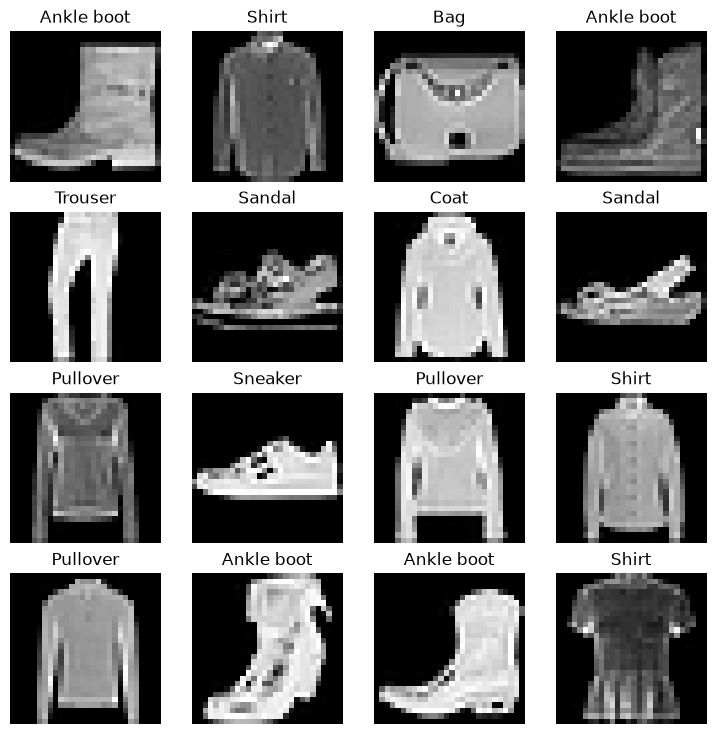

In [6]:
#Let's plot more images
torch.manual_seed(42)

fig=plt.figure(figsize=(9,9))
row,col=4,4
for i in range (1, row*col +1):
  random_idx= torch.randint(0,len(train_data), size=[1]).item()
  image, label= train_data[random_idx]
  fig.add_subplot(row,col,i)
  plt.imshow(image.squeeze(), cmap='gray')
  plt.title(train_data.classes[label])
  plt.axis(False);




In [7]:
# We need to divide the data into batches
# it's very computaitonally expensive to forward pass the whole dataset at once
from torch.utils.data import DataLoader
BATCH_SIZE= 32
train_dataloader= DataLoader(train_data,
                             batch_size=BATCH_SIZE,
                             shuffle=True)
test_dataloader= DataLoader(test_data,
                            batch_size= BATCH_SIZE,
                            shuffle=False)


In [8]:
train_features_batch, train_labels_batch= next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

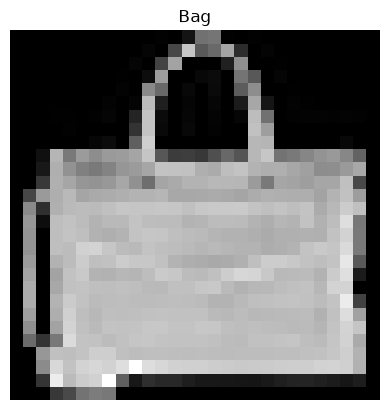

In [9]:
# The data is the same now, just divided randomly into batches of 32
# let's visualize a random sample

random_idx= torch.randint(0, len(train_features_batch), size=(1,)).item()
img, label= train_features_batch[random_idx],train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap='gray')
plt.title(train_data.classes[label])
plt.axis('off')

# Model 0: Build a baseline model

In [10]:
# We are going to use a plain NN -> we need to flatten the images

x=train_features_batch[0]
flatten_model= nn.Flatten() # it's a model structure (needs an instance then forward pass)
output= flatten_model(x)
print (f"shape before flattening: {x.shape}")
print (f"shape after flattening: {output.shape}")

shape before flattening: torch.Size([1, 28, 28])
shape after flattening: torch.Size([1, 784])


In [11]:
# Build model_0

class FashionMNISTModelV0(nn.Module):
  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()
    self.layer_stack=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=output_shape)
    )

  def forward(self, x):
    return self.layer_stack(x)

torch.manual_seed(42)
model_0= FashionMNISTModelV0(input_shape= 784,
                             hidden_units=10,
                             output_shape=len(train_data.classes))

Let's try and compare the difference between training on cpu and gpu

In [12]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  # Note: you need the "raw" GitHub URL for this to work
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

helper_functions.py already exists, skipping download


In [13]:
model_0.to('cpu') # we'll start by using the cpu
# we need an optimizer & loss funct
optimizer_0= torch.optim.SGD(params=model_0.parameters(), lr=0.1)
loss_fn= nn.CrossEntropyLoss()

from helper_functions import accuracy_fn


Let's create a function to time our experiments

In [14]:
from timeit import default_timer as timer
def print_train_time( start, end, device=None):
  total_time= end-start
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time

In [15]:
# Import tqdm for progress bar
from tqdm.auto import tqdm

# Set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# Set the number of epochs (we'll keep this small for faster training times)
epochs = 3

# Create training and testing loop
for epoch in range(epochs):
    print(f"Epoch: {epoch}\n-------")
    ### Training
    train_loss = 0
    # Add a loop to loop through training batches
    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train()
        # 1. Forward pass
        y_pred = model_0(X)

        # 2. Calculate loss (per batch)
        loss = loss_fn(y_pred, y)
        train_loss += loss # accumulatively add up the loss per batch

        # 3. Optimizer zero grad
        optimizer_0.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer_0.step()

        # Print out how many samples have been seen
        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

    # Divide total train loss by length of train dataloader (average loss per batch per epoch)
    train_loss /= len(train_dataloader)

    ### Testing
    # Setup variables for accumulatively adding up loss and accuracy
    test_loss, test_acc = 0, 0
    model_0.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            # 1. Forward pass
            test_pred = model_0(X)

            # 2. Calculate loss (accumulatively)
            test_loss += loss_fn(test_pred, y) # accumulatively add up the loss per epoch

            # 3. Calculate accuracy (preds need to be same as y_true)
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))

        # Calculations on test metrics need to happen inside torch.inference_mode()
        # Divide total test loss by length of test dataloader (per batch)
        test_loss /= len(test_dataloader)

        # Divide total accuracy by length of test dataloader (per batch)
        test_acc /= len(test_dataloader)

    ## Print out what's happening
    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

# Calculate training time
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu,
                                           end=train_time_end_on_cpu,
                                           device=str(next(model_0.parameters()).device))

Epoch: 0
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.59039 | Test loss: 0.50954, Test acc: 82.04%

Epoch: 1
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.47633 | Test loss: 0.47989, Test acc: 83.20%

Epoch: 2
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.45503 | Test loss: 0.47664, Test acc: 83.43%

Train time on cpu: 28.171 seconds


In [16]:
torch.manual_seed(42)
def model_eval(model, data_loader, loss_fn, accuracy_fn, device='cpu', get_pred =False):
  y_preds=[]
  model.eval()
  with torch.inference_mode():
    test_loss,  test_acc=0,0
    for X,y in data_loader:
      X,y= X.to(device), y.to(device)
      test_logits=model(X)
      test_loss += loss_fn(test_logits, y)
      test_acc += accuracy_fn(y_true=y, y_pred=test_logits.argmax(dim=1))

      y_pred= torch.softmax(test_logits, dim=1).argmax(dim=1)
      y_preds.append(y_pred.cpu())

    test_loss/= len(data_loader)
    test_acc/= len(data_loader)

  if get_pred:
    return   torch.cat(y_preds)
  else:
    return {"model_name": model.__class__.__name__,
           "model_loss": test_loss.item(),
            "model_acc": test_acc}

# Calculate model_0 results on test dataset
model_0_results = model_eval(model_0, test_dataloader, loss_fn, accuracy_fn)
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663888335227966,
 'model_acc': 83.42651757188499}

In [17]:
# Let's setup device agnostic code
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## Let's try a non-linear model now

# Model 1: Building a better model with non-linearity

In [18]:
# Build model_1

class FashionMNISTModelV1(nn.Module):
  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()
    self.layer_stack=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_shape),
        nn.ReLU()
    )

  def forward(self, x):
    return self.layer_stack(x)

torch.manual_seed(42)
model_1= FashionMNISTModelV1(input_shape= 784,
                             hidden_units=10,
                             output_shape=len(train_data.classes)).to(device)

In [19]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer_1 = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)

Let's functionize the train & test steps

In [20]:
def train_step(model, data_loader,
               loss_fn, optimizer,
               accuracy_fn, device):
  train_loss, train_acc= 0,0

  model.to(device)
  model.train()

  for batch, (X,y) in enumerate(data_loader):
    X,y= X.to(device), y.to(device)
    y_pred= model(X)
    loss= loss_fn(y_pred, y)
    train_loss += loss
    train_acc+= accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss/= len(data_loader)
  train_acc/= len(data_loader)
  print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

def test_step(model, data_loader,
              loss_fn, optimizer,
              accuracy_fn, device):
  test_loss, test_acc= 0,0

  model.to(device)
  model.eval()
  with torch.inference_mode():
    for X,y in data_loader:
      X,y= X.to(device), y.to(device)
      test_logits= model(X)
      test_loss += loss_fn(test_logits, y)
      test_acc += accuracy_fn(y_true=y,
                              y_pred=test_logits.argmax(dim=1))
    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")



In [21]:
# training loop
train_time_start_on_gpu= timer()

epochs =3
for epoch in range(epochs):
  print(f"Epoch: {epoch}\n-------")
  train_step(model=model_1,
             data_loader=train_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer_1,
             accuracy_fn=accuracy_fn,
             device=device)
  test_step(model=model_1,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer_1,
            accuracy_fn=accuracy_fn,
            device=device)
train_time_end_on_gpu= timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,
                                            end=train_time_end_on_gpu,
                                            device=device)

Epoch: 0
-------
Train loss: 1.05878 | Train accuracy: 62.19%
Test loss: 0.99506 | Test accuracy: 64.13%

Epoch: 1
-------
Train loss: 0.91331 | Train accuracy: 66.40%
Test loss: 0.90508 | Test accuracy: 66.86%

Epoch: 2
-------
Train loss: 0.87982 | Train accuracy: 67.24%
Test loss: 0.89476 | Test accuracy: 66.46%

Train time on cuda: 30.875 seconds


In [22]:
model_1_results= model_eval(model_1, test_dataloader, loss_fn, accuracy_fn, device)
model_1_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.8947635889053345,
 'model_acc': 66.46365814696486}

It appears the non-linear model performs worst than our baseline model!

# Model 2: CNN

Let's recreate the TinyVGG from the [CNN explainer](https://poloclub.github.io/cnn-explainer/) website

In [23]:
class FashionMNISTModelV2(nn.Module):

  def __init__(self, input_shape, hidden_units, output_shape):
    super().__init__()
    self.stack_1= nn.Sequential(
        nn.Conv2d(in_channels= input_shape, out_channels= hidden_units,
                  kernel_size=3, stride=1,padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels= hidden_units, out_channels= hidden_units,
                  kernel_size=3, stride=1, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
    )
    self.stack_2= nn.Sequential(
        nn.Conv2d(hidden_units, hidden_units,3, padding=1),
        nn.ReLU(),
        nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.classifier= nn.Sequential(
        nn.Flatten(),
        nn.Linear(hidden_units*7*7, output_shape)
    )

  def forward(self,X):
    X= self.stack_1(X)
    X= self.stack_2(X)
    X= self.classifier(X)
    return X

torch.manual_seed(42)
model_2= FashionMNISTModelV2(input_shape=1,
                             hidden_units=10,
                             output_shape=len(train_data.classes)).to(device)
model_2

FashionMNISTModelV2(
  (stack_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (stack_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [24]:
# loss function & optimizer
loss_fn= nn.CrossEntropyLoss()
optimizer_2= torch.optim.SGD(params= model_2.parameters(), lr= 0.1)

In [25]:
# train
torch.manual_seed(42)

train_time_start_model_2=timer()

epochs=3
for epoch in range(epochs):
  print(f"Epoch: {epoch}\n--------------")
  train_step(model=model_2,
             data_loader=train_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer_2,
             accuracy_fn=accuracy_fn,
             device=device)
  test_step(model=model_2,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer_2,
            accuracy_fn=accuracy_fn,
            device=device)
train_time_end_model_2= timer()
total_train_time_model_2= print_train_time(start=train_time_start_model_2,
                                            end=train_time_end_model_2,
                                            device=device)




Epoch: 0
--------------
Train loss: 0.59037 | Train accuracy: 78.56%
Test loss: 0.39011 | Test accuracy: 85.98%

Epoch: 1
--------------
Train loss: 0.36345 | Train accuracy: 86.91%
Test loss: 0.35201 | Test accuracy: 86.80%

Epoch: 2
--------------
Train loss: 0.32469 | Train accuracy: 88.23%
Test loss: 0.32185 | Test accuracy: 88.24%

Train time on cuda: 38.850 seconds


In [26]:
# model_2 results
model_2_results= model_eval(model_2, test_dataloader, loss_fn, accuracy_fn, device)
model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.32185080647468567,
 'model_acc': 88.2388178913738}

## Let's compare the 3 models:

In [27]:
# We'll create a dataframe for comparison
import pandas as pd
compare_results= pd.DataFrame([model_0_results,model_1_results, model_2_results])
compare_results["training_time"]=[f"{total_train_time_model_0:.3f}",
                                   f"{total_train_time_model_1:.3f}",
                                   f"{total_train_time_model_2:.3f}"]
compare_results

,model_name,model_loss,model_acc,training_time
0,FashionMNISTModelV0,0.476639,83.426518,28.171
1,FashionMNISTModelV1,0.894764,66.463658,30.875
2,FashionMNISTModelV2,0.321851,88.238818,38.850


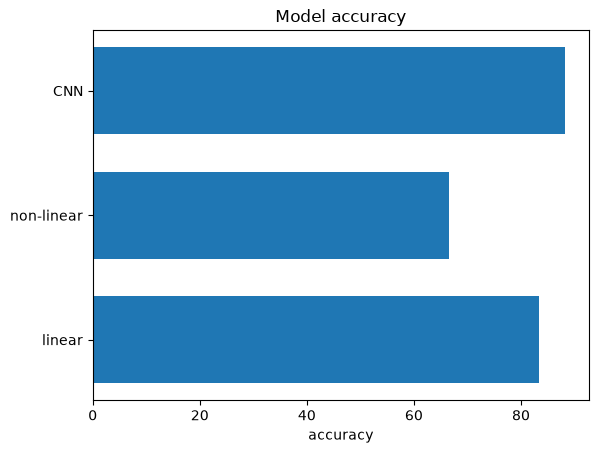

In [28]:
plt.barh(y=["linear","non-linear","CNN"], width=compare_results["model_acc"], height=0.7)
plt.title("Model accuracy")
plt.xlabel("accuracy")
plt.show()

## Let's make random evaluation of the best performing model:

In [29]:
def make_predictions( model, test_sample: list, device):
  preds=[]
  for sample in test_sample:
    logit= model(sample.unsqueeze(dim=0).to(device))
    pred_logit= torch.softmax(logit.squeeze(), dim=0)
    pred_label= torch.argmax(pred_logit).cpu()
    preds.append(pred_label.item())

  return preds



In [30]:
import random
torch.manual_seed(42)
test_samples=[]
test_labels=[]
for sample, label in random.sample(list(test_data), k=9):
  test_samples.append(sample)
  test_labels.append(label)

preds= make_predictions(model_2, test_samples, device)
preds, test_labels

([6, 5, 0, 8, 4, 9, 7, 2, 0], [6, 5, 6, 8, 4, 9, 7, 2, 2])

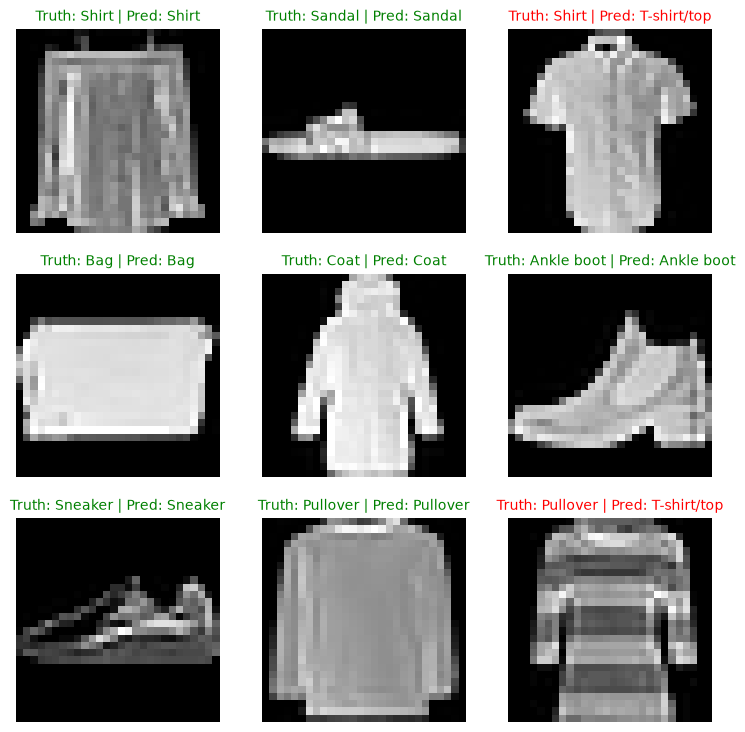

In [31]:
# Plot predictions
plt.figure(figsize=(9,9))
for i, sample in enumerate(test_samples):
  plt.subplot(3,3,i+1)
  plt.imshow(sample.squeeze(), cmap='gray')
  truth_label= train_data.classes[test_labels[i]]
  pred_label= train_data.classes[preds[i]]
  title_text= f"Truth: {truth_label} | Pred: {pred_label}"

  if pred_label== truth_label:
    plt.title(title_text, fontsize=10, c='g')
  else:
    plt.title(title_text, fontsize= 10, c="r")
  plt.axis('off')
plt.show()





In [32]:
# See if torchmetrics exists, if not, install it
try:
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")
    assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtend verison should be 0.19.0 or higher"
except:
    !pip install -q torchmetrics -U mlxtend # <- Note: If you're using Google Colab, this may require restarting the runtime
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")

mlxtend version: 0.25.0


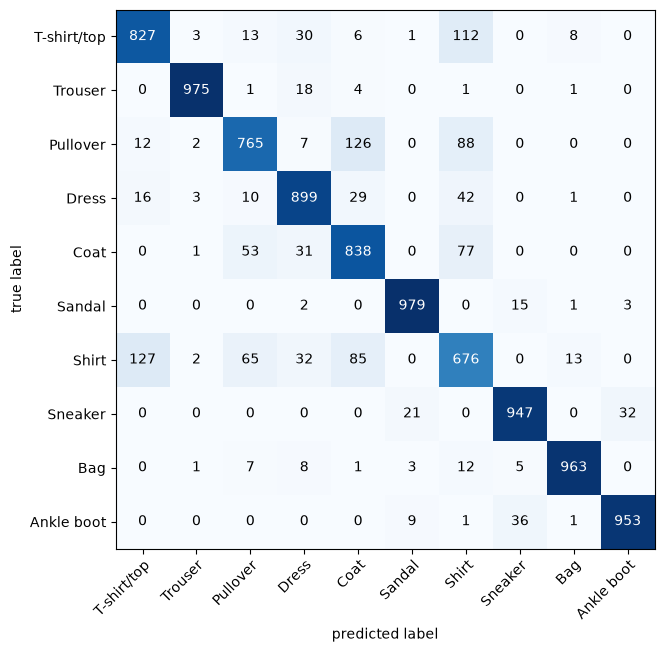

In [33]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

class_names= train_data.classes
y_pred_tensor= model_eval( model_2, test_dataloader, loss_fn,
                          accuracy_fn,device, get_pred= True)
confmat= ConfusionMatrix(num_classes= len(class_names), task='multiclass')
confmat_tensor= confmat(preds= y_pred_tensor,
                        target=test_data.targets)
fig, ax= plot_confusion_matrix(conf_mat= confmat_tensor.numpy(),
                               class_names= class_names,
                               figsize=(10,7))




